# DispersionWellenpaket


Program shows dispersion of an optical pulse propagating in a fiber.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Parameters

Spatial and temporal discretization.

In [2]:
xend = 500
xsteps = 4096*2
x = np.linspace(0, xend, xsteps)
deltax = xend/xsteps
tp = 20
x0 = 10*tp

tend = 250
tsteps = 500
t = np.linspace(0, tend, tsteps)
deltat = tend/tsteps

vph_0 = 10.0
# vd = 0                        # dispersion parameter = 0 m/s
vd = -5                         # dispersion parameter = -0.7 m/s
lambda0 = 2.0                   # wavelength in m
k0 = 2*np.pi/lambda0            # wave number

## Optical Fiber Pulse Propagation

### Gaussian pulse

$$
u(t) = A \exp\left(-\frac{t^2}{2 t_0^2}\right)
$$

### Dispersion evolution

$$
\tilde{a}(\omega, z) = \tilde{a}(\omega,0)
\exp\left(i \frac{k_0''}{2} \omega^2 z \right)
$$

### Pulse broadening

$$
t_z = \sqrt{t_0^2 + \frac{(k_0'' z)^2}{t_0^2}}
$$

### Power

$$
P(t,z) = |u(t,z)|^2
$$

### Input parameters

In [3]:
N = 1024            # total number of points kept in time window
T_domain = 100      # total time domain kept [ps]
t_FWHM_0 = 20       # initial pulse FWHM [ps]
P_0 = 1             # initial peak power [mW]
D = -1              # dispersion coefficient [ps/nm-km]
z_plot = np.array([0,100,200,500])  # z values to plot [km]

### Derived parameters

In [4]:
Delta_t = T_domain/N                   # node spacing in time
Delta_om = 2*np.pi/T_domain            # node spacing in radial frequency
Amp = np.sqrt(P_0)                     # initial amplitude of the Gaussian

t_0 = t_FWHM_0/(2*np.sqrt(np.log(2)))  # initial pulse standard deviation
k_0_dp = -1.2*D                        # translation to ps^2/km

### Input vectors

In [5]:
t_vec = Delta_t*np.arange(-N/2, N/2)        # create array of time points
om_vec = Delta_om*np.arange(-N/2, N/2)      # create array of radial frequency points

u_vec = Amp*np.exp(-(t_vec**2)/(2*t_0**2))  # create array of initial amplitudes

### Shift arrays for FFT convention

In [6]:
a_vec = np.zeros_like(u_vec, dtype=complex)
a_vec[:N//2] = u_vec[N//2:]
a_vec[N//2:] = u_vec[:N//2]

om_vec_square_shift = np.zeros_like(om_vec)
om_vec_square_shift[:N//2] = om_vec[N//2:]**2
om_vec_square_shift[N//2:] = om_vec[:N//2]**2

### Initial Fourier transform

Inverse FFT (physics convention)

In [7]:
a_tilde_vec = np.fft.ifft(a_vec, N)

## Propagation loop and visualization 

Determines the pulse evolution along the fiber.

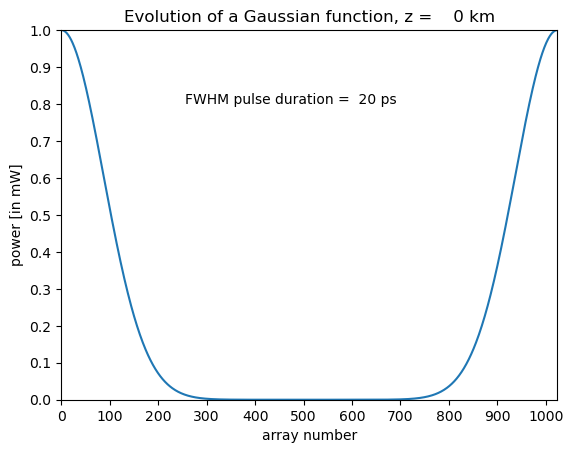

Press Enter to continue... 


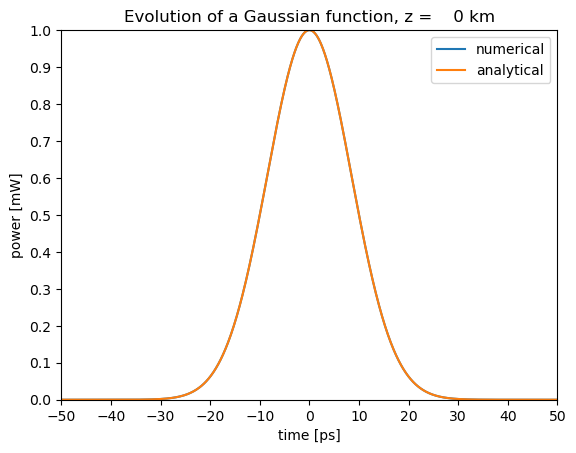

Press Enter to continue... 


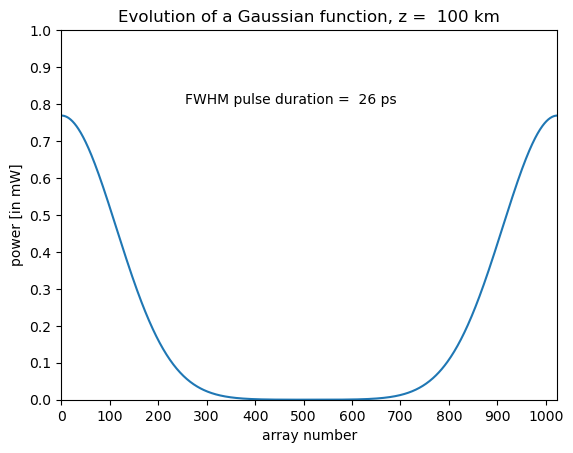

Press Enter to continue... 


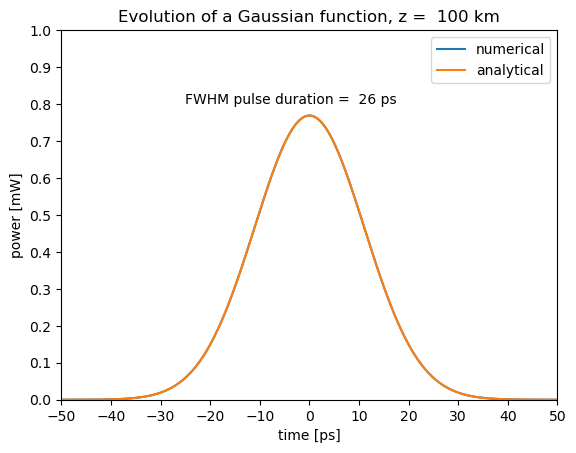

Press Enter to continue... 


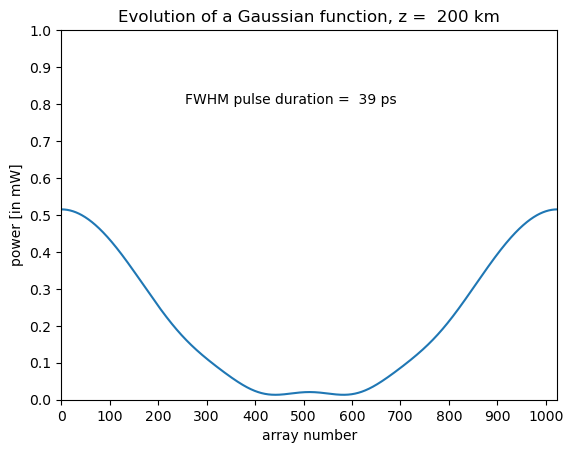

Press Enter to continue... 


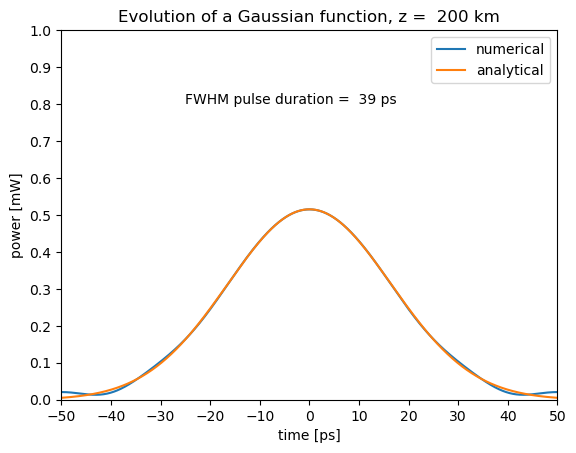

Press Enter to continue... 


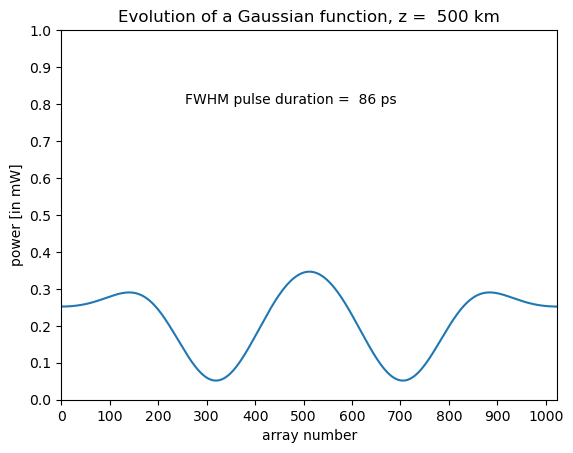

Press Enter to continue... 


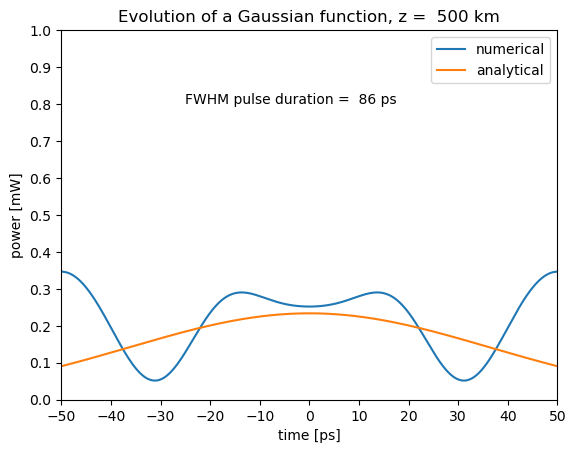

Press Enter to continue... 


In [8]:
n_plot = len(z_plot)

for i_plot in range(n_plot):

    # Determine the z value and exponential factor for evolution
    z_val = z_plot[i_plot]
    factor = np.exp((1j/2)*k_0_dp*om_vec_square_shift*z_val)

    # Carry out the z shift and transform to time domain
    a_tilde_vec_z = a_tilde_vec * factor
    a_vec_z = np.fft.fft(a_tilde_vec_z, N)

    # Calculate power as function of array number
    P_a_z = a_vec_z*np.conj(a_vec_z)

    P_u_z = np.zeros_like(P_a_z)
    P_u_z[:N//2] = P_a_z[N//2:]
    P_u_z[N//2:] = P_a_z[:N//2]

    # Analytical comparison solution
    t_z = np.sqrt(t_0**2 + (k_0_dp*z_val)**2/t_0**2)
    t_FWHM_z = 2*np.sqrt(np.log(2))*t_z

    P_comp_z = P_0*(t_0/t_z)*np.exp(-(t_vec**2)/(t_z**2))

    # Plot power as function of array number
    plt.figure()
    plt.plot(P_a_z.real)
    plt.xlim(1, N)
    plt.ylim(0, P_0)
    plt.xticks(np.arange(0, N+1, 100))
    plt.yticks(np.arange(0, P_0+0.1, 0.1))
    plt.xlabel('array number')
    plt.ylabel('power [in mW]')
    plt.title(f'Evolution of a Gaussian function, z = {z_val:4.0f} km')
    plt.text(0.25*N, 0.8*P_0,
             f'FWHM pulse duration = {t_FWHM_z:3.0f} ps')
    plt.show()

    input('Press Enter to continue...')

    # Plot power as function of time
    plt.figure()
    plt.plot(t_vec, P_u_z.real, label='numerical')
    plt.plot(t_vec, P_comp_z, label='analytical')

    plt.xlim(-50, 50)
    plt.ylim(0, P_0)
    plt.xticks(np.arange(-50, 51, 10))
    plt.yticks(np.arange(0, P_0+0.1, 0.1))
    plt.xlabel('time [ps]')
    plt.ylabel('power [mW]')
    plt.title(f'Evolution of a Gaussian function, z = {z_val:4.0f} km')

    if t_0/t_z < 0.8:
        plt.text(-0.25*T_domain, 0.8*P_0,
                 f'FWHM pulse duration = {t_FWHM_z:3.0f} ps')

    plt.legend()
    plt.show()

    input('Press Enter to continue...')